In [1]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd

PROJECT = "ab-test-portfolio-509820"
client = bigquery.Client(project=PROJECT)

df = client.query(f"""
    SELECT user_id, event_ts, test_group, converted, country
    FROM `{PROJECT}.ab_test.clean_ab_data`
""").to_dataframe()

print(df.shape)
df.groupby("test_group")["converted"].agg(users="count", conversions="sum", rate="mean")

(286690, 5)


,users,conversions,rate
test_group,,,
control,143293,17220,0.120173
treatment,143397,17025,0.118726


In [2]:
from scipy.stats import chisquare

counts = df["test_group"].value_counts().sort_index()
srm_stat, srm_p = chisquare(counts.values)   # expected = equal split by default
print(counts.to_dict())
print(f"SRM chi2 = {srm_stat:.4f}, p = {srm_p:.4f}  ->  {'FAIL' if srm_p < 0.001 else 'PASS'}")

{'control': 143293, 'treatment': 143397}
SRM chi2 = 0.0377, p = 0.8460  ->  PASS


In [3]:
import numpy as np
from scipy.stats import norm
from statsmodels.stats.proportion import proportions_ztest

def ab_summary(conv_c, n_c, conv_t, n_t, alpha=0.05):
    p_c, p_t = conv_c / n_c, conv_t / n_t
    diff = p_t - p_c
    zc = norm.ppf(1 - alpha / 2)

    # Hypothesis test: pooled SE (statsmodels default)
    z, p_value = proportions_ztest([conv_t, conv_c], [n_t, n_c], alternative="two-sided")

    # CI for absolute difference: unpooled SE
    se_diff = np.sqrt(p_c * (1 - p_c) / n_c + p_t * (1 - p_t) / n_t)

    # CI for relative lift: delta method on log(p_t / p_c)
    se_log = np.sqrt((1 - p_c) / (n_c * p_c) + (1 - p_t) / (n_t * p_t))
    log_rr = np.log(p_t / p_c)

    return {
        "n_control": n_c, "n_treatment": n_t,
        "cr_control": p_c, "cr_treatment": p_t,
        "abs_lift": diff,
        "abs_ci_low": diff - zc * se_diff, "abs_ci_high": diff + zc * se_diff,
        "rel_lift": p_t / p_c - 1,
        "rel_ci_low": np.exp(log_rr - zc * se_log) - 1,
        "rel_ci_high": np.exp(log_rr + zc * se_log) - 1,
        "z": z, "p_value": p_value,
    }

g = df.groupby("test_group")["converted"].agg(["sum", "count"])
main = ab_summary(g.loc["control", "sum"], g.loc["control", "count"],
                  g.loc["treatment", "sum"], g.loc["treatment", "count"])
pd.Series(main).to_frame("value")

,value
n_control,143293.000000
n_treatment,143397.000000
cr_control,0.120173
cr_treatment,0.118726
abs_lift,-0.001447
abs_ci_low,-0.003821
abs_ci_high,0.000927
rel_lift,-0.012041
rel_ci_low,-0.031485
rel_ci_high,0.007794


In [4]:
from scipy.stats import chi2_contingency

table = np.array([
    [g.loc["control", "sum"],   g.loc["control", "count"]   - g.loc["control", "sum"]],
    [g.loc["treatment", "sum"], g.loc["treatment", "count"] - g.loc["treatment", "sum"]],
])
chi2_stat, chi2_p, _, _ = chi2_contingency(table, correction=False)
print(f"chi2 = {chi2_stat:.4f}, p = {chi2_p:.4f}, z^2 = {main['z']**2:.4f}")

chi2 = 1.4268, p = 0.2323, z^2 = 1.4268


In [5]:
def mde_abs(p_base, n_per_arm, alpha=0.05, power=0.80):
    return (norm.ppf(1 - alpha / 2) + norm.ppf(power)) * np.sqrt(2 * p_base * (1 - p_base) / n_per_arm)

def n_required(p_base, abs_effect, alpha=0.05, power=0.80):
    return ((norm.ppf(1 - alpha / 2) + norm.ppf(power)) ** 2 * 2 * p_base * (1 - p_base)) / abs_effect ** 2

p_base = main["cr_control"]
n_arm = (main["n_control"] + main["n_treatment"]) / 2
duration_days = (df["event_ts"].max() - df["event_ts"].min()).total_seconds() / 86400
users_per_day = len(df) / duration_days

mde = mde_abs(p_base, n_arm)
n_obs = n_required(p_base, abs(main["abs_lift"]))

print(f"Test duration:          {duration_days:.2f} days, {users_per_day:,.0f} users/day")
print(f"MDE (80% power):        {mde*100:.3f} pp absolute, {mde/p_base*100:.2f}% relative")
print(f"n/arm to detect |observed diff|: {n_obs:,.0f}  "
      f"(~{2*n_obs/users_per_day:,.0f} days at current traffic)")

Test duration:          22.00 days, 13,031 users/day
MDE (80% power):        0.340 pp absolute, 2.83% relative
n/arm to detect |observed diff|: 792,675  (~122 days at current traffic)


In [6]:
itt = client.query(f"""
WITH ranked AS (
  SELECT r.*,
         ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY event_ts) AS rn,
         COUNT(DISTINCT test_group) OVER (PARTITION BY user_id)     AS n_groups
  FROM `{PROJECT}.ab_test.raw_ab_data` r
)
SELECT test_group, converted
FROM ranked
WHERE rn = 1 AND n_groups = 1
""").to_dataframe()

gi = itt.groupby("test_group")["converted"].agg(["sum", "count"])
itt_res = ab_summary(gi.loc["control", "sum"], gi.loc["control", "count"],
                     gi.loc["treatment", "sum"], gi.loc["treatment", "count"])

pd.DataFrame({"per_protocol (main)": main, "by_assignment (sensitivity)": itt_res})

,per_protocol (main),by_assignment (sensitivity)
n_control,143293.000000,144300.000000
n_treatment,143397.000000,144389.000000
cr_control,0.120173,0.120402
cr_treatment,0.118726,0.118769
abs_lift,-0.001447,-0.001633
abs_ci_low,-0.003821,-0.004000
abs_ci_high,0.000927,0.000735
rel_lift,-0.012041,-0.013559
rel_ci_low,-0.031485,-0.032894
rel_ci_high,0.007794,0.006163


In [7]:
from statsmodels.stats.multitest import multipletests

df["weekday"] = df["event_ts"].dt.strftime("%u-%a")

def segment_table(data, col):
    rows = []
    for val, sub in data.groupby(col):
        s = sub.groupby("test_group")["converted"].agg(["sum", "count"])
        r = ab_summary(s.loc["control", "sum"], s.loc["control", "count"],
                       s.loc["treatment", "sum"], s.loc["treatment", "count"])
        r.update(segment=col, value=val)
        rows.append(r)
    return pd.DataFrame(rows)

seg = pd.concat([segment_table(df, "country"), segment_table(df, "weekday")], ignore_index=True)
seg["p_holm"] = multipletests(seg["p_value"], method="holm")[1]

out = seg[["segment", "value", "n_control", "n_treatment", "cr_control", "cr_treatment",
           "abs_lift", "abs_ci_low", "abs_ci_high", "p_value", "p_holm"]].copy()
for c in ["cr_control", "cr_treatment", "abs_lift", "abs_ci_low", "abs_ci_high"]:
    out[c] = (out[c] * 100).round(3)          # percentage points
out.round({"p_value": 4, "p_holm": 4})

,segment,value,n_control,n_treatment,cr_control,cr_treatment,abs_lift,abs_ci_low,abs_ci_high,p_value,p_holm
0,country,CA,7094,7209,11.897,11.236,-0.661,-1.710,0.387,0.2162,1.0000
1,country,UK,35883,35630,11.969,12.116,0.147,-0.330,0.624,0.5466,1.0000
2,country,US,100316,100558,12.043,11.832,-0.211,-0.495,0.073,0.1448,1.0000
3,weekday,1-Mon,22483,22324,12.298,11.960,-0.338,-0.943,0.267,0.2732,1.0000
4,weekday,2-Tue,23305,23225,11.684,12.207,0.522,-0.067,1.112,0.0823,0.7406
5,weekday,3-Wed,19478,19549,12.096,11.868,-0.228,-0.872,0.416,0.4878,1.0000
6,weekday,4-Thu,19264,19444,12.168,11.747,-0.421,-1.068,0.225,0.2016,1.0000
7,weekday,5-Fri,19436,19676,11.546,11.766,0.220,-0.416,0.856,0.4978,1.0000
8,weekday,6-Sat,19626,19509,12.387,11.754,-0.633,-1.279,0.012,0.0546,0.5460
9,weekday,7-Sun,19701,19670,11.964,11.734,-0.230,-0.869,0.408,0.4797,1.0000


In [8]:
import statsmodels.formula.api as smf
from scipy.stats import chi2

df["treat"] = (df["test_group"] == "treatment").astype(int)

for col in ["country", "weekday"]:
    m0 = smf.logit(f"converted ~ treat + C({col})", data=df).fit(disp=0)
    m1 = smf.logit(f"converted ~ treat * C({col})", data=df).fit(disp=0)
    lr = 2 * (m1.llf - m0.llf)
    k = int(m1.df_model - m0.df_model)
    print(f"{col:8s}  LR = {lr:.3f}, df = {k}, p = {chi2.sf(lr, k):.4f}")

country   LR = 2.602, df = 2, p = 0.2723
weekday   LR = 9.574, df = 6, p = 0.1438


In [9]:
from statsmodels.stats.contingency_tables import StratifiedTable

cty = seg[seg["segment"] == "country"].copy()
w = (cty["n_control"] + cty["n_treatment"]) / (cty["n_control"] + cty["n_treatment"]).sum()
stratified_diff = (w * cty["abs_lift"]).sum()

tables = []
for c in cty["value"]:
    s = df[df["country"] == c].groupby("test_group")["converted"].agg(["sum", "count"])
    tables.append(np.array([
        [s.loc["treatment", "sum"], s.loc["treatment", "count"] - s.loc["treatment", "sum"]],
        [s.loc["control", "sum"],   s.loc["control", "count"]   - s.loc["control", "sum"]],
    ]))
st = StratifiedTable(tables)

print(f"Pooled abs lift:                  {main['abs_lift']*100:.4f} pp")
print(f"Country-stratified abs lift:      {stratified_diff*100:.4f} pp")
print(f"CMH pooled odds ratio:            {st.oddsratio_pooled:.4f}")
print(f"CMH test p-value (OR = 1):        {st.test_null_odds().pvalue:.4f}")

Pooled abs lift:                  -0.1447 pp
Country-stratified abs lift:      -0.1442 pp
CMH pooled odds ratio:            0.9864
CMH test p-value (OR = 1):        0.2339


In [10]:
# ---- ASSUMPTIONS (not in the data; stated explicitly) ----
USERS_PER_YEAR = users_per_day * 365   # traffic continues at the test's observed rate (13,031/day)
VALUE_PER_CONVERSION = 100             # illustrative $ value per conversion; replace with a real figure if known
# -----------------------------------------------------------

impact = pd.DataFrame({
    "scenario": ["point estimate", "95% CI low", "95% CI high"],
    "abs_lift": [main["abs_lift"], main["abs_ci_low"], main["abs_ci_high"]],
})
impact["conversions_per_100k_users"] = impact["abs_lift"] * 100_000
impact["conversions_per_year"]       = impact["abs_lift"] * USERS_PER_YEAR
impact["revenue_per_year_usd"]       = impact["conversions_per_year"] * VALUE_PER_CONVERSION
impact.round(1).assign(abs_lift=impact["abs_lift"].round(5))

,scenario,abs_lift,conversions_per_100k_users,conversions_per_year,revenue_per_year_usd
0,point estimate,-0.00145,-144.7,-6882.7,-688270.5
1,95% CI low,-0.00382,-382.1,-18176.1,-1817614.4
2,95% CI high,0.00093,92.7,4410.7,441073.5


In [11]:
results = pd.concat([pd.DataFrame([{**main, "segment": "overall", "value": "All users"}]), seg],
                    ignore_index=True)
results["label"] = results["segment"] + ": " + results["value"]
for c in ["cr_control", "cr_treatment", "abs_lift", "abs_ci_low", "abs_ci_high",
          "rel_lift", "rel_ci_low", "rel_ci_high"]:
    results[c] = results[c] * 100            # percent / percentage points
results[["n_control", "n_treatment"]] = results[["n_control", "n_treatment"]].astype(int)

cols = ["segment", "value", "label", "n_control", "n_treatment", "cr_control", "cr_treatment",
        "abs_lift", "abs_ci_low", "abs_ci_high", "rel_lift", "rel_ci_low", "rel_ci_high",
        "p_value", "p_holm"]

job = client.load_table_from_dataframe(
    results[cols], f"{PROJECT}.ab_test.dash_results",
    job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE"))
job.result()
print(client.get_table(f"{PROJECT}.ab_test.dash_results").num_rows, "rows written")

11 rows written


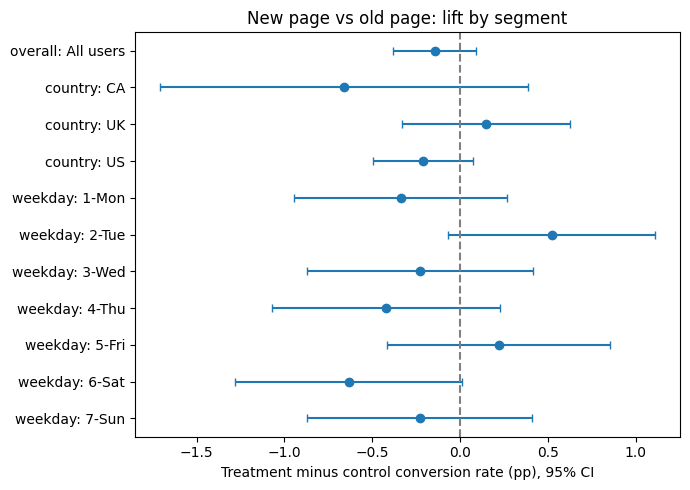

In [12]:
import matplotlib.pyplot as plt

p = results.iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(p["abs_lift"], range(len(p)),
            xerr=[p["abs_lift"] - p["abs_ci_low"], p["abs_ci_high"] - p["abs_lift"]],
            fmt="o", capsize=3)
ax.axvline(0, linestyle="--", color="gray")
ax.set_yticks(range(len(p)))
ax.set_yticklabels(p["label"])
ax.set_xlabel("Treatment minus control conversion rate (pp), 95% CI")
ax.set_title("New page vs old page: lift by segment")
plt.tight_layout()
plt.savefig("lift_by_segment.png", dpi=150)
plt.show()